🤖 PHASE 3: Predictive Machine Learning


3.1 What Can We Predict?

Target – Model Type – Difficulty
Race winner (top 3 finish) – Classification – ⭐⭐
Podium probability per driver – Classification – ⭐⭐
Driver championship winner – Classification – ⭐⭐⭐
Lap time prediction – Regression – ⭐⭐
Points scored per race – Regression – ⭐⭐

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

DATA_PATH = '/Users/tizianogallo/Desktop/Github/f1-analysis/data/'
EXPORT_PATH = '/Users/tizianogallo/Desktop/Github/f1-analysis/exports/'

races        = pd.read_csv(DATA_PATH + 'races.csv')
results      = pd.read_csv(DATA_PATH + 'results.csv')
drivers      = pd.read_csv(DATA_PATH + 'drivers.csv')
constructors = pd.read_csv(DATA_PATH + 'constructors.csv')
lap_times    = pd.read_csv(DATA_PATH + 'lap_times.csv')
pit_stops    = pd.read_csv(DATA_PATH + 'pit_stops.csv')
qualifying   = pd.read_csv(DATA_PATH + 'qualifying.csv')
standings    = pd.read_csv(DATA_PATH + 'driver_standings.csv')
circuits     = pd.read_csv(DATA_PATH + 'circuits.csv')

In [6]:
for df in [results, qualifying, lap_times, pit_stops]:
    df.replace('\\N', np.nan, inplace=True)

results['position']       = pd.to_numeric(results['positionOrder'], errors='coerce')
results['grid']           = pd.to_numeric(results['grid'], errors='coerce')
results['points']         = pd.to_numeric(results['points'], errors='coerce')
results['milliseconds']   = pd.to_numeric(results['milliseconds'], errors='coerce')
lap_times['milliseconds'] = pd.to_numeric(lap_times['milliseconds'], errors='coerce')
drivers['full_name']      = drivers['forename'] + ' ' + drivers['surname']
results = results.merge(races[['raceId', 'year', 'circuitId']], on='raceId')

def time_to_ms(t):
    try:
        m, s = str(t).split(':')
        return int(m) * 60000 + float(s) * 1000
    except:
        return np.nan

for col in ['q1', 'q2', 'q3']:
    qualifying[f'{col}_ms'] = qualifying[col].apply(time_to_ms)

3.2 Feature Engineering

In [8]:
from sklearn.preprocessing import LabelEncoder

# Build master modeling dataset
model_df = results.merge(races[['raceId','year','round','circuitId']], on='raceId')
model_df = model_df.merge(qualifying[['raceId','driverId','q1_ms','q2_ms','q3_ms']], 
                          on=['raceId','driverId'], how='left')
model_df = model_df.merge(pit_stops.groupby(['raceId','driverId'])
                          .agg(pit_count=('stop','count'), avg_pit_ms=('milliseconds','mean'))
                          .reset_index(), on=['raceId','driverId'], how='left')

# Target: podium (top 3)
model_df['podium'] = (model_df['positionOrder'] <= 3).astype(int)

# Rolling stats: driver's avg points over last 5 races
model_df = model_df.sort_values(['driverId','year','round'])
model_df['rolling_points_5'] = (model_df.groupby('driverId')['points']
                                  .transform(lambda x: x.shift(1).rolling(5).mean()))

# Grid position as key predictor
model_df['grid_position'] = pd.to_numeric(model_df['grid'], errors='coerce')

# Best qualifying time (Q3 if available, else Q2, else Q1)
model_df['best_qual_ms'] = model_df['q3_ms'].fillna(model_df['q2_ms']).fillna(model_df['q1_ms'])

# Encode categoricals
le = LabelEncoder()
model_df['circuit_enc']      = le.fit_transform(model_df['circuitId'].astype(str))
model_df['constructor_enc']  = le.fit_transform(model_df['constructorId'].astype(str))
model_df['driver_enc']       = le.fit_transform(model_df['driverId'].astype(str))

3.3 Train a Podium Prediction Model

In [9]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

FEATURES = [
    'grid_position', 'best_qual_ms', 'rolling_points_5',
    'pit_count', 'avg_pit_ms', 'circuit_enc', 
    'constructor_enc', 'driver_enc', 'round', 'year'
]

# Use 2010+ for modern regulation consistency
df_model = model_df[model_df['year'] >= 2010].dropna(subset=['podium'])
X = df_model[FEATURES]
y = df_model['podium']

# Train on pre-2023, test on 2023–2024
train_mask = df_model['year'] < 2023
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# Pipeline: impute + model
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, 
                                          max_depth=4, random_state=42))
])
pipe.fit(X_train, y_train)

# Evaluate
y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       781
           1       0.70      0.59      0.64       138

    accuracy                           0.90       919
   macro avg       0.82      0.77      0.79       919
weighted avg       0.90      0.90      0.90       919

ROC-AUC: 0.9349


3.4 Feature Importance

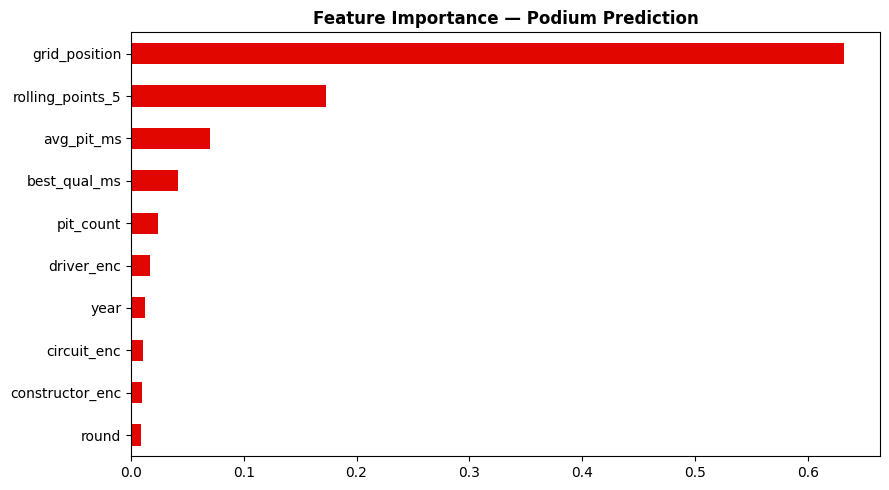

In [14]:
import matplotlib.pyplot as plt

feature_imp = pd.Series(
    pipe.named_steps['model'].feature_importances_, 
    index=FEATURES
).sort_values(ascending=True)

feature_imp.plot(kind='barh', color='#e10600', figsize=(9, 5))
plt.title('Feature Importance — Podium Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig(EXPORT_PATH + 'feature_importance.png', dpi=150)
plt.show()

3.5 Championship Winner Prediction (per season)

In [15]:
# Predict end-of-season champion using mid-season standing
champ_df = standings.merge(races[['raceId','year','round']], on='raceId')
champ_df = champ_df.sort_values(['year','round'])

# Label: was this driver champion that year?
champions = (champ_df.groupby(['year','driverId'])['points']
             .max().reset_index()
             .sort_values('points', ascending=False)
             .groupby('year').first().reset_index()
             .rename(columns={'driverId': 'champion_id'}))

# Feature: points after race 10 (mid-season snapshot)
mid = champ_df[champ_df['round'] == 10][['year','driverId','points','position']]
mid = mid.merge(champions[['year','champion_id']], on='year')
mid['is_champion'] = (mid['driverId'] == mid['champion_id']).astype(int)

X_champ = mid[['points','position']]
y_champ = mid['is_champion']

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_champ, y_champ)
print(f"Mid-season champion accuracy: {rf.score(X_champ, y_champ):.3f}")

Mid-season champion accuracy: 0.995


3.6 Regression Model — Predict Points Scored + Adjusted R-Squared

In [16]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import numpy as np

FEATURES = [
    'grid_position', 'best_qual_ms', 'rolling_points_5',
    'pit_count', 'avg_pit_ms', 'circuit_enc',
    'constructor_enc', 'driver_enc', 'round', 'year'
]

# Target is now continuous: points scored
df_reg = model_df[model_df['year'] >= 2010].dropna(subset=['points'])
X_reg = df_reg[FEATURES]
y_reg = df_reg['points']

train_mask = df_reg['year'] < 2023
X_train, X_test = X_reg[train_mask], X_reg[~train_mask]
y_train, y_test = y_reg[train_mask], y_reg[~train_mask]

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Train Gradient Boosting Regressor
reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                 max_depth=4, random_state=42)
reg.fit(X_train_imp, y_train)
y_pred = reg.predict(X_test_imp)

In [17]:
# ── Adjusted R-Squared & Evaluation Metrics ───────────────────────────────────
n = len(y_test)           # number of observations
k = X_test_imp.shape[1]  # number of features

r2     = r2_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
mae    = mean_absolute_error(y_test, y_pred)

print("=" * 40)
print(f"  R-Squared:          {r2:.4f}")
print(f"  Adjusted R-Squared: {adj_r2:.4f}")
print(f"  RMSE:               {rmse:.4f} points")
print(f"  MAE:                {mae:.4f} points")
print("=" * 40)

  R-Squared:          0.6719
  Adjusted R-Squared: 0.6682
  RMSE:               4.1455 points
  MAE:                2.7500 points


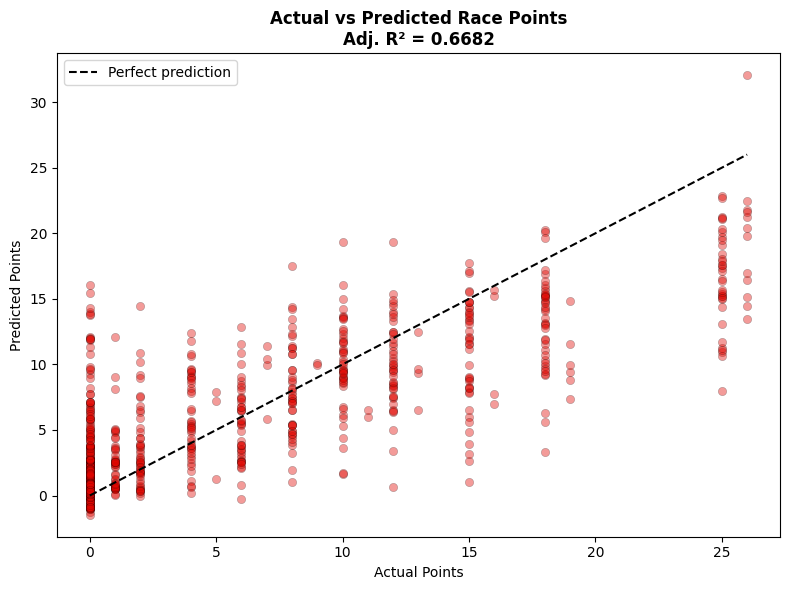

In [18]:
# ── Actual vs Predicted Points Plot ───────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='#e10600', edgecolors='black', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'k--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Points')
plt.ylabel('Predicted Points')
plt.title(f'Actual vs Predicted Race Points\nAdj. R² = {adj_r2:.4f}', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_PATH + 'regression_actual_vs_predicted.png', dpi=150)
plt.show()

In [33]:
era_wins = results[pd.to_numeric(results['positionOrder'], errors='coerce') == 1].merge(
    constructors[['constructorId','name']], on='constructorId'
).merge(races[['raceId','year']], on='raceId')

era_wins['era'] = pd.cut(era_wins['year'], 
    bins=[1949,1979,1999,2013,2024], 
    labels=['1950s–70s','1980s–90s','2000s–13','2014–24'])

print(era_wins.shape)

(1128, 21)


In [34]:
drivers['full_name'] = drivers['forename'] + ' ' + drivers['surname']

# Export modeling dataset with predictions and adding the full name
df_model = df_model.merge(drivers[['driverId','full_name']], on='driverId', how='left')

df_model['podium_probability'] = pipe.predict_proba(
    SimpleImputer(strategy='median').fit_transform(df_model[FEATURES])
)[:, 1]

export_tables = {
    'f1_results_enriched': df_model,
    'f1_constructor_wins': era_wins,
    'f1_driver_profile': drivers.merge(
        results.groupby('driverId').agg(
            total_points=('points','sum'),
            total_wins=('positionOrder', lambda x: (x==1).sum()),
            total_races=('positionOrder','count')
        ).reset_index(), on='driverId'
    )
}

for name, df in export_tables.items():
    df.to_csv(EXPORT_PATH + f'{name}.csv', index=False)
    print(f"Exported: {name}.csv")

Exported: f1_results_enriched.csv
Exported: f1_constructor_wins.csv
Exported: f1_driver_profile.csv


/Users/tizianogallo/Desktop/Github/f1-analysis/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
